# Coursework Set Week 7

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Anna Stroeve
* Username: agstroeve
* Student number: S5995035
* Group (AS1, etc.): AS2

-----

In [ ]:
totalpoints = currentpoints = 0

### Simpson's rule (4 pt)  <font color='red'><b>COURSEWORK</b></font>

In section 'Simpson's rule' in the task documentation we plotted the function $f(x) = 1 + x + \sin(2x)$

* Create a object-oriented code that the input variables are a function you wish to integral in string and the integral intervals, `a` and `b`.
* Add a function in the object that calculates the integration with the Trapezium rule.
* Add a function in the object that calculates the integration with the Simpson’s rule.
* Add a function in the object that calculates the integration with Monte Carlo integration.
* Add a function in the object that calculates the integration with SymPy (``sympy.integrate()``).
* Add a function in the object that calculates the integration with SciPy (``quad()`` function).
* Use ``a=0.5`` and ``b=3.0`` as the test using all methods you create in the object. Print the test.
  
**Answers**:  

In [90]:
import numpy as np
from scipy.integrate import quad
import sympy as sp
import random
import math
from scipy import integrate

class integration:
    def __init__(self, func, a, b):
        self.func = func
        self.a = a
        self.b = b
       
    def trapezium(self):
        area_t = (self.b-self.a)*((self.func(self.a)+self.func(self.b))/2)
        return area_t

    def simpson(self, n):
        if n%2 == 0: 
            x = np.linspace(self.a, self.b, n+1)  #subintervals, n+1 because n intervals means n points
            y = np.array([self.func(i) for i in x])  #f(x) for all values 
            h = (self.b - self.a)/n  
            return h/3 * (y[0] + y[-1] + 4*y[1:-1:2].sum() + 2*y[2:-1:2].sum()) # use sums and slicing for the even and uneven x 
        else: 
            print(f"n must be even")  # simpson only works for even n 

    def monte_carlo(self, m):
        x = np.random.uniform(self.a, self.b, m) #m random numbers between a and b 
        y = np.array([self.func(i) for i in x])  #f(x) for all numbers 
        return (self.b-self.a) * np.mean(y)  #divide the part between a and b by the average y-value

    def sympy_i(self):
        x = sp.Symbol('x')  # define x as symbol
        area = sp.integrate(self.func(x), (x, self.a, self.b))  # do the integration 
        return area

    def scipy_i(self):
        area, _ = quad(self.func, self.a, self.b)  #_ because it also returns the error which i do not need. 
        return area
        
def f(x): 
    return 1 + x + np.sin(2*x)

def g(x):
    return 1 + x + sp.sin(2*x)

example = integration(f, 0.5, 3.0)
example_s = integration(g, 0.5, 3.0)  # two different functions, using sympy.sin and numpy.sin as not all methods work with each

print(f"Trapezium: {example.trapezium()}")
print(f"Simpson: {example.simpson(100)}")
print(f"Monte Carlo: {example.monte_carlo(100)}")
print(f"Sympy = {example_s.sympy_i()}")
print(f"Area = {example.scipy_i()}")


Trapezium: 7.577569358261213
Simpson: 6.665066002317341
Monte Carlo: 6.543398829735486
Sympy = 6.66506600960889
Area = 6.6650660096088865


In [80]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

NameError: name 'totalpoints' is not defined

### Fitting a Gaussian model for velocity profile data (16 pt) <font color='red'><b>COURSEWORK</b></font>

For this assignment we use the HI radio FITS cube
[ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)

It contains 101 channel maps with radio interferometer HI data.

1. (3 pt) A global HI profile is a set of measurements at fixed R.A. and Dec. as function of the spectral 
   axis (frequency or velocity). It shows at which frequency (or velocity) there is a peak in HI.
   Plot this profile for R.A. (x) index 58 and Dec. (y) index 55. 
   Label the X axis with the header value ``CUNIT3`` and the Y axis with the intensity 
   units in ``BUNIT``. For this data, the pixels represent brightness.
   
   In the global profile, the first pixel corresponds to 233 km/s and the last pixel corresponds to 377 km/s.
   Convert your X axis from pixel index numbers to km/s (use NumPy's ``linspace()`` to define the X values).
   
**Answer**:

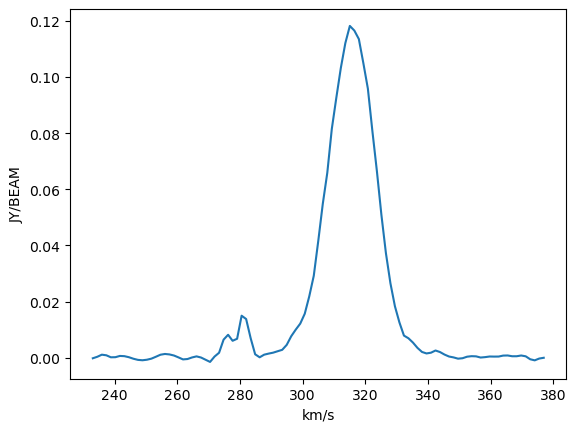

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

hdul = fits.open("ngc6946.fits")
data = hdul[0].data
header = hdul[0].header

spectrum = data[:, 55, 58]  # data at x=58, y=55
velocity = np.linspace(233, 377, len(spectrum)) #create equal steps between 233 and 377 using the amount of pixels

plt.plot(velocity, spectrum) # plot velocity against the extracted spectrum (58, 55)
plt.xlabel(header["CUNIT3"])  # use the header from cunit3 as xlabel 
plt.ylabel(header["BUNIT"])   # use the header from bunit as xlabel 
plt.show()  # show the plot 

In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

2. (1 pt) Assume the profile can be modeled by a Gaussian. Make a function with signature:

          def f(x, amp, mu, sigma, zero):

   which returns the value of a Gaussian function with amplitude ``amp`` centered at
   position ``mu`` with width ``sigma`` and offset with respect to the x axis of ``zero``
   
**Answer**:   

In [3]:
import numpy as np 

def f(x, amp, mu, sigma, zero):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-(x - mu)**2 / (2 * sigma**2)) + zero 

# the gaussian function is f(x) = (1 / (σ√(2π))) e^(-(x - μ)² / (2σ²))

In [ ]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Remember how to distinguish linear- from non-linear models. Always look at the derivatives to the parameters.

3. (1 pt) Give a simple proof that this function ``f`` represents a non-linear model

**Answer**:

In [4]:
# f is linear if its derivative with respect to something is not dependent on that what it's derived with respect to. 
# this function f is non-linear because its derivative with respect to mu depends on mu 

In [ ]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Initial estimates are essential for a good fit. If they are not close enough to the real values, you can find a fit but without a guarantee that it is the best fit.

4. (3 pt) For a least squares fit with function `scipy.optimize.curve_fit()` we need reasonable initial estimates. Find reasonable estimates and motivate why you think they are reasonable and then use them as argument ``p0`` in ``curve_fit()`` to find the best fit model parameters and their (scaled) standard errors    

**Answer**:

In [5]:
import numpy as np 
from scipy.optimize import curve_fit
p0=[0.11, 315, 15, 0]
# for amplitude use the approximate maximum of the curve
# for mu use the center of the curve
# for sigma use 15. the peak is about 30 wide, so from the center the deviation would be large until around 15, after that
    # it's much smaller 
# for zero use the minimum of the spectrum; so 0

popt, pcov = curve_fit(f, velocity, spectrum, p0=p0)  #
stderr = np.sqrt(np.diag(pcov))  #standard error 

/tmp/ipykernel_2504840/1729172069.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(f, velocity, spectrum, p0=p0)  #


In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

5. (1 pt) Plot the model curve with its best fit parameter together with the data points    

**Answer**:

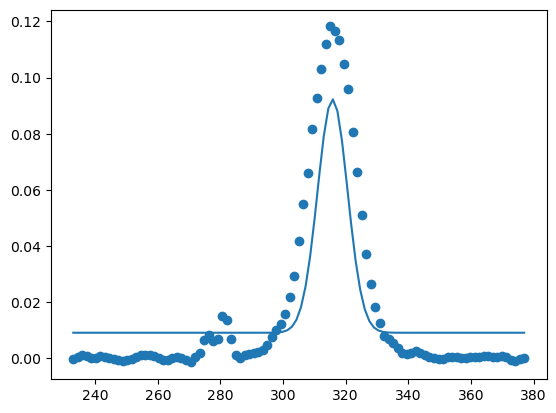

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

X = np.linspace(velocity[0], velocity[-1], 100)  #100 points between the first and last value 
Y = f(X, *popt)  #use the x_fit and unpack the fitted model parameters to create y_fit 
plt.scatter(velocity, spectrum)  #scatter plot of the data 
plt.plot(X, Y)  #plot the model curve 
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Fitting multiple signals with a Gaussian.

6. (3 pt) If you fit is alright, you see that a small signal at the left of the main signal in your
   profile has not been fitted. You can add a second Gaussian (without a zero level because you 
   already have one offset) to model that second signal.
   Find the best fit parameter of this composed model and plot original data with the best fit curve 
   
**Answer**:

/tmp/ipykernel_2504840/2811472897.py:5: OptimizeWarning: Covariance of the parameters could not be estimated
  popt2, pcov2 = curve_fit(f, velocity, spectrum, p0=p1)


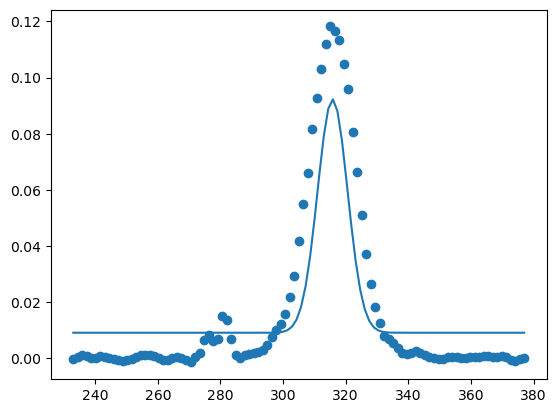

In [10]:
import matplotlib.pyplot as plt
import numpy as np

p1=[0.11, 315, 15, -1]
popt2, pcov2 = curve_fit(f, velocity, spectrum, p0=p1)
X2 = np.linspace(velocity[0], velocity[-1], 100) 
Y2 = f(X, *popt2)  #use the x_fit and unpack the fitted model parameters to create y_fit 
plt.scatter(velocity, spectrum)  #scatter plot of the data 
plt.plot(X2, Y2)  #plot the model curve 
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

An important characterization of a peak is its width. In astronomy we use the FWHM.

7. (2 pt) What is the FWHM of the gas in the main peak and in the secondary peak. Also give the standard errors 
   in the FWHM. Do not forget to print the units
   
**Answer**:

In [28]:
from math import sqrt, log, exp


sigma=
f = 2*sigma*sqrt(2*log(2,exp(1)))  # formula for FWHM


SyntaxError: invalid syntax (3212522097.py, line 4)

In [ ]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

8. (2 pt) Plot the FWHM's in the previous plot as horizontal lines at the positions of the fitted peak centers.
   Make the plot complete with labels, title and useful legend



**Answer**:

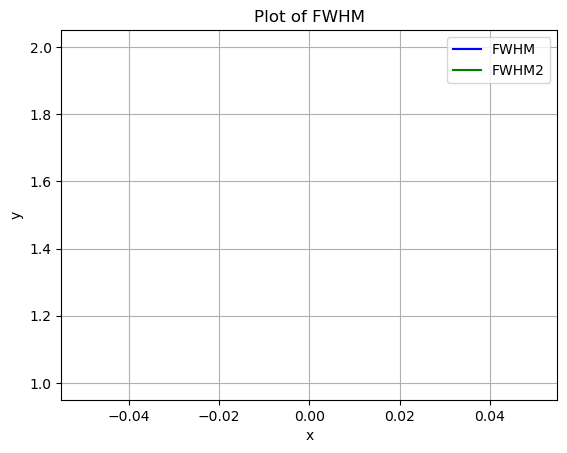

In [16]:
plt.figure()
plt.plot(x, label='FWHM', color='blue')
plt.plot(x2, label='FWHM2', color='green')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Plot of FWHM')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

### Smoothing a noisy image (5pt) <font color='red'><b>COURSEWORK</b></font>

Given is a noisy image of a galaxy in FITS file
[faintgalaxy.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/faintgalaxy.fits).
 
To improve the signal to noise ratio in this image, one can smooth the data with a simple algorithm.
    
1. Write a function ``smooth()`` with the following properties:

   * It has an argument ``M`` which is a 2D input image.
   * It returns an output image ``Mc`` with the same shape as the input image.
   * The input and output images do not share memory.
   * Each pixel at location ``(i,j)`` in the output image is the **mean** of 9 input pixels located at:
            
   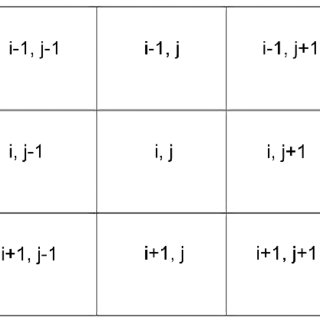    
       
   * Border pixels can be ignored and set to 0.0.
   * Interpolation is not needed.

<br>

2. Create a mosaic with two plots. One shows an image of the original data and the other shows the smoothed version. 
3. Use the function ``smooth2()`` below to smooth ``M`` with a SciPy routine and plot the result.
   
```python
    def smooth2(M):
        Mc = ndimage.gaussian_filter(M, sigma=(1,1), order=0)
        return Mc
```
    
**Strategy**

* The function should leave the original image unaltered, that is, we need to create a copy using one of:

     1. method ``copy()`` 
     1. ``np.zeros()`` 
     1. ``np.zeros_like()`` <br>&nbsp;<br>
   
* For each position (x, y) in the output image, we need to set some value except for the borders:

```python
    for y in range(1, ny-1):
        for x in range(1, nx-1):
```

* Or one uses function numpy.ndindex() and skips the index that represents a border pixel (gives faster code).
* The value of the pixel becomes the average of 9 neighbours in the input. We should then extract a sub-image 
  of 3x3 pixels centered at ``(x,y)``.
* For a 2dim structure ``M``, the pixel at ``(x,y)`` is given by ``M[y,x]``.
* The indices in ``M`` can be a range. To include the left and right, upper and lower neighbours of ``x``,
  we would write ``M[x-1:x+2, y-1:y+2]``.

**Answers**:

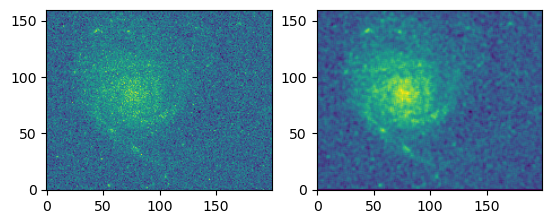

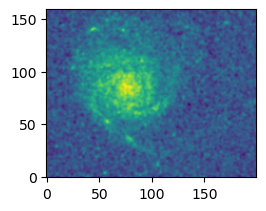

In [115]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import ndimage

hdul = fits.open("faintgalaxy.fits")  #open fits file 
M = hdul[0].data  # define M as data in the file 
header = hdul[0].header

hdul.close()        

ny, nx = M.shape
def smooth(M):
    Mc = M.copy()  #copy image M 
    Mc[:] = 0  #set everything to 0 so that border pixels are 0 
    for y in range(1, ny-1):
        for x in range(1, nx-1):
            Mc[y,x] = M[y-1:y+2, x-1:x+2].mean()  #select above, below and current row/column and find average
    return Mc

def smooth2(M):
    Mc2 = ndimage.gaussian_filter(M, sigma=(1,1), order=0)
    return Mc2

Mc=smooth(M)
Mc2=smooth2(M)
plt.subplot(1,2,1)
plt.imshow(M, origin='lower')
plt.subplot(1,2,2)
plt.imshow(Mc, origin='lower')
plt.show()
plt.subplot(2,2,2)
plt.imshow(Mc2, origin='lower')


In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")